# Tess Follow Up Proposals

This notebook is the final part of a follow-up observation on TESS objects of interest (TOIs). The ultimate goal is to create a list of TOIs observable from Sutherland, South Africa. The list will be used to plan follow-up observations with the SAAO 1.0m telescope. In part 1, I gathered a list of transiting exoplanets which have more than 2 comparisons in the Mookodi field of view. In part 2, I determined which of these objects have transits which are visible at night from Sutherland during my observing run in mid-February. Now, according to a list of parameters, I will select for interesting TOIs to observe.

I chose to select for TOIs with potential T Tauri stars, as a significant portion of exoplanet research today is focused on what young stellar objects (YSOs) can reveal about exoplanet formation. To this end, I selected for:
- Stellar radii around 1.5-6.5 solar radii
- Masses near 1.0-1.3 solar masses
- Effective temperatures between 4000-6000 K
- Must be a planet candidate (PC)

Unfortunately, we don't have spectra of the stars, so I can't confirm that they are T Tauri stars, but these parameters are a good start. I also selected for stars which have a high SG3 priority, as these are potentially interesting targets for follow-up observations.

In [55]:
# importing necessary liibraries
import pandas as pd
import pyvo as vo
import pandas as pd
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.table import Table
from regions import CircleSkyRegion
from regions import Regions
from io import BytesIO
import math
import requests
from astropy.io import fits
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.patches import Rectangle
import matplotlib.text as mpl_text

In [42]:
# reading the TESS TOI file and displaying the first few rows
toi = pd.read_csv('../Tables/TESS_TOI_28Jan2025_Mookodi_Transits.csv')
toi

,TIC ID,TOI,Previous CTOI,Master,SG1A,SG1B,SG2,SG3,SG4,SG5,...,Date TOI Alerted (UTC),Date TOI Updated (UTC),Date Modified,Comments,RA (deg),Dec (deg),Mookodi Comp,SHOC Comp,Num Transits,Transit Times
0,382188882,276.01,NaN,5,5,5,5,5,5,5,...,2018-11-30,2023-11-01,2023-11-03 12:13:21,TFOP FP/SB1,81.353083,-55.019925,4,2,1,2025-02-18 20:46:55;2025-02-18 22:46:44
1,349518800,407.01,NaN,5,5,5,5,3,5,5,...,2019-01-16,2023-10-02,2023-10-02 00:00:00,TFOP SB1/APC,111.211708,-62.092431,13,2,2,2025-02-12 22:27:12;2025-02-13 01:51:41;2025-0...
2,4616072,466.01,NaN,5,5,5,5,5,5,5,...,2019-02-22,2021-10-07,2022-12-14 12:09:24,HATS-45 b,101.994250,-21.910711,35,3,1,2025-02-23 19:23:59;2025-02-23 22:24:24
3,47911178,471.01,NaN,5,5,5,5,5,5,5,...,2019-02-27,2021-10-07,2022-12-14 12:09:24,WASP-101 b,98.351083,-23.486086,3,1,1,2025-02-22 17:50:00;2025-02-22 20:32:26
4,52640302,473.01,NaN,5,5,5,5,5,5,5,...,2019-02-22,2021-10-07,2022-12-14 12:09:24,WASP-64 b,101.114917,-32.858389,26,1,2,2025-02-12 20:08:59;2025-02-12 22:34:42;2025-0...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,256124756,6637.01,NaN,3,4,3,3,1,4,4,...,2023-08-15,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,199.577125,-59.758683,40,3,1,2025-02-18 22:16:10;2025-02-19 00:03:55
250,343717397,6747.01,NaN,3,4,3,3,1,4,4,...,2023-11-02,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,273.029333,-72.877347,25,4,2,2025-02-19 02:36:22;2025-02-19 03:20:21;2025-0...
251,259884973,6823.01,TIC 259884973.01,3,4,3,3,3,4,4,...,2023-11-02,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,40.756292,-70.514283,16,2,1,2025-02-22 17:49:15;2025-02-22 19:48:50
252,55363630,6854.01,NaN,3,4,3,3,1,4,4,...,2023-12-12,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,77.014958,-65.049061,49,3,1,2025-02-22 19:38:21;2025-02-22 20:51:04


In [43]:
# filtering the data
toi_filtered = toi[
    (toi['Stellar Radius (R_Sun)'] > 1.5) &
    (toi['Stellar Radius (R_Sun)'] < 6.5) &
    (toi['Stellar Mass (M_Sun)'] < 3.0) &
    (toi['Stellar Eff Temp (K)'] > 4000) &
    (toi['Stellar Eff Temp (K)'] < 6000) &
    (toi['TFOPWG Disposition'] == 'PC') &
    (toi['SG3'] == 1) &
    (toi['Mookodi Comp'] >= 3)
]

toi_filtered

,TIC ID,TOI,Previous CTOI,Master,SG1A,SG1B,SG2,SG3,SG4,SG5,...,Date TOI Alerted (UTC),Date TOI Updated (UTC),Date Modified,Comments,RA (deg),Dec (deg),Mookodi Comp,SHOC Comp,Num Transits,Transit Times
56,51830822,2727.01,NaN,3,4,3,3,1,4,4,...,2021-06-03,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,97.895708,-34.882869,28,4,4,2025-02-12 21:37:02;2025-02-12 22:47:07;2025-0...
62,52869977,2852.01,NaN,3,4,3,3,1,4,4,...,2021-06-04,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,102.114000,-32.457697,53,5,7,2025-02-13 21:26:45;2025-02-13 22:19:54;2025-0...
86,384034837,3007.01,NaN,3,4,3,3,1,4,4,...,2021-06-04,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,135.639875,-56.012800,149,14,1,2025-02-18 17:58:14;2025-02-18 22:33:23
169,157127081,4767.01,NaN,3,4,3,3,1,4,4,...,2021-12-21,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,104.997792,-36.319389,22,1,1,2025-02-20 18:27:08;2025-02-20 22:21:55
199,376421071,4927.01,NaN,3,4,3,3,1,4,4,...,2021-12-21,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,153.244625,-65.847247,91,7,6,2025-02-12 21:42:52;2025-02-12 22:56:54;2025-0...
218,396649769,5039.01,NaN,3,4,3,3,1,4,4,...,2022-01-06,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,214.410125,-75.324247,47,3,1,2025-02-24 23:42:13;2025-02-25 03:27:09
220,407146538,5055.01,NaN,3,4,3,3,1,4,4,...,2022-01-06,2024-08-22,2024-08-22 00:00:00,V-shaped; found in faint-star QLP search,235.152833,-81.208242,4,0,1,2025-02-19 22:31:07;2025-02-20 02:09:09
247,374155286,6584.01,NaN,3,4,3,3,1,4,4,...,2023-07-20,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,149.911375,-62.975497,33,3,1,2025-02-21 23:22:23;2025-02-22 01:13:55


Now that I have the filtered stars, I can select the three stars I want to propose. I selected TOIs 2852.01, 4767.01, and 4927.01. I chose stars 2852.01 and 4927.01 for their high number of transits and decent SNR, and I chose star 4767.01 solely based on its high SNR. All of the stars are viewable by Mookodi, and stars 2852.01 and 4927.01 are viewable by SHOC.


In [46]:
# selecting final TOIs
final_TOIs = toi_filtered.iloc[[1, 3, 4]]
final_TOIs

,TIC ID,TOI,Previous CTOI,Master,SG1A,SG1B,SG2,SG3,SG4,SG5,...,Date TOI Alerted (UTC),Date TOI Updated (UTC),Date Modified,Comments,RA (deg),Dec (deg),Mookodi Comp,SHOC Comp,Num Transits,Transit Times
62,52869977,2852.01,NaN,3,4,3,3,1,4,4,...,2021-06-04,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,102.114000,-32.457697,53,5,7,2025-02-13 21:26:45;2025-02-13 22:19:54;2025-0...
169,157127081,4767.01,NaN,3,4,3,3,1,4,4,...,2021-12-21,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,104.997792,-36.319389,22,1,1,2025-02-20 18:27:08;2025-02-20 22:21:55
199,376421071,4927.01,NaN,3,4,3,3,1,4,4,...,2021-12-21,2024-08-22,2024-08-22 00:00:00,found in faint-star QLP search,153.244625,-65.847247,91,7,6,2025-02-12 21:42:52;2025-02-12 22:56:54;2025-0...


In [67]:
# function definitions for getting the image
def get_cleaned_star_df(ra, dec):

    tap_query = ("SELECT DISTANCE(POINT('ICRS', raj2000, dej2000), POINT('ICRS', "
              + ra + ", " + dec +
              ")) AS dist, "  +
              "m.object_id,m.raj2000,m.dej2000,m.g_flags,m.g_nimaflags,m.i_flags,m.i_nimaflags, " +
            "m.g_psf,m.e_g_psf,m.i_psf,m.e_i_psf  FROM dr2.master AS m " +
              "WHERE 1 = CONTAINS(POINT('ICRS', raj2000, dej2000), "
              "CIRCLE('ICRS',"  +
               ra +", "+ dec +
              ", 0.083 )) ORDER BY dist " )

    tap_service = vo.dal.TAPService("https://api.skymapper.nci.org.au/public/tap/")
    tap_results =  tap_service.search(tap_query)

    astropy_table = tap_results.to_table()
    df = astropy_table.to_pandas()
    if df['dist'].iloc[0] > 0.00056 :
        print("We have a problem, distance > 2 arcsconds")
        raise SystemExit("Stop right there!")

    g_good1 = df['g_flags'] == 0
    g_good2 = df['g_nimaflags'] == 0
    g_good3 = df['e_g_psf'] < 0.022
    i_good1 = df['i_flags'] == 0
    i_good2 = df['i_nimaflags'] == 0
    i_good3 = df['e_i_psf'] < 0.022

    #combine these comparisons to make a new dataframe
    # using df_good = df.query('g_flags == 0 ') does not work, as some of the values are null...
    df_good = df[g_good1 & g_good2 & g_good3 & i_good1 & i_good2 & i_good3]

    return df_good

def get_mookodi_stars(df_good, magnitude):
    i_brightcut = magnitude - 0.5
    i_faintcut = magnitude + 4.0

    i_bright = df_good['i_psf'] > i_brightcut
    i_faint = df_good['i_psf'] < i_faintcut

    # Create an explicit copy of the filtered DataFrame
    df_mookodi = df_good[i_bright & i_faint].copy()
    return df_mookodi


def generate_image(df_mookodi, ra, dec, toi):
    shoc_comp = df_mookodi['dist'] < 0.0233

    my_https_query = ("https://skyview.gsfc.nasa.gov/cgi-bin/images?Survey=digitized+sky+survey&position="
                 + ra + "," + dec +
                 "&Size=0.1667&Return=FITS")
    #print(my_https_query)


    #try using DR3 for the filename
    file_name = "TOI" + str(toi) + ".fits"
    #print(file_name)

    r=requests.get(my_https_query)
    with open(file_name, "wb") as f:
        f.write(r.content)

    with fits.open(BytesIO(r.content)) as hdul:
       hdr=hdul[0].header
       red_image=hdul[0].data

    return hdr, red_image

def ellipse_plot(ax, x, y, size, a, b, theta, f_colour, e_colour):
    """
    Function to plot an ellipse on a CCD image.

    Keyword arguments:
    ax          -- matplotlib axis object to plot on
    x           -- x-axis pixel coordinate centre of ellipse
    y           -- y-axis pixel coordinate centre of ellipse
    a           -- semi-major axis of ellipse
    b           -- semi-minor axis of ellipse
    f_colour    -- facecolour of ellipse
    e_colour    -- edge colour of ellipse
    """
    e = Ellipse(xy=(x, y), width=2.*size*a, height=2.*size*b,
                angle=theta * 180. / np.pi)
    e.set_facecolor(f_colour)
    e.set_edgecolor(e_colour)
    ax.add_artist(e)
    plt.draw()

def plot_image(hdr, red_image, toi, df_mookodi):
    xlength = hdr['NAXIS1']
    xcenpix = hdr['CRPIX1']
    racen = hdr['CRVAL1']
    rascale = hdr['CDELT1']
    ylength = hdr['NAXIS2']
    ycenpix = hdr['CRPIX2']
    deccen = hdr['CRVAL2']
    decscale = hdr['CDELT2']

    decadjust = math.cos(math.radians(deccen))

    # Use .loc for assignment
    df_mookodi.loc[:, 'xpix'] = xcenpix - (racen - df_mookodi['raj2000'])/rascale*decadjust
    df_mookodi.loc[:, 'ypix'] = ycenpix - (deccen - df_mookodi['dej2000'])/decscale

    shoc_x = xcenpix - (1.42/60.0)/rascale*decadjust
    shoc_y = ycenpix - (1.42/60.0)/decscale
    shoc_width = (2.85/60.0)/rascale*decadjust
    shoc_height = (2.85/60.0)/decscale

    fig3, ax = plt.subplots(figsize=(15, 15), num=3)
    plt.subplots_adjust(left=0.15, right=0.9, top=0.95, bottom=0.15)
    m, s = np.mean(red_image), np.std(red_image)
    im = ax.imshow(red_image, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')

    # Remove the axes
    ax.axis('off')

    ellipse_plot(ax, xlength/2.0, ylength/2.0, 2, 2, 2, 0, 'none', 'red')
    ellipse_plot(ax, xlength/2.0, ylength/2.0, 1, 1, 1, 0, 'none', 'red')

    rect = Rectangle((shoc_x, shoc_y), shoc_width, shoc_height, linewidth=3, edgecolor='g', facecolor='none')
    ax.add_patch(rect)

    mytext = mpl_text.Text(x=xcenpix, y=10,
                text="TOI " + str(toi),
                color='black',
                backgroundcolor='white',
                verticalalignment='center',
                horizontalalignment='center',
                fontsize=32)
    ax.add_artist(mytext)

    for index, row in df_mookodi.iterrows():
        xx = row['xpix']
        yy = row['ypix']
        ellipse_plot(ax, xx, yy, 2, 2, 2, 0, 'none', 'red')

    # Save the plot to a file
    plt.savefig(f'TOI_{toi}.png')

    return plt.show()

def get_toi_image(ra, dec, toi, magnitude):
    df_good = get_cleaned_star_df(ra, dec)
    df_mookodi = get_mookodi_stars(df_good, magnitude)
    hdr, red_image = generate_image(df_mookodi, ra, dec, toi)
    return plot_image(hdr, red_image, toi, df_mookodi)


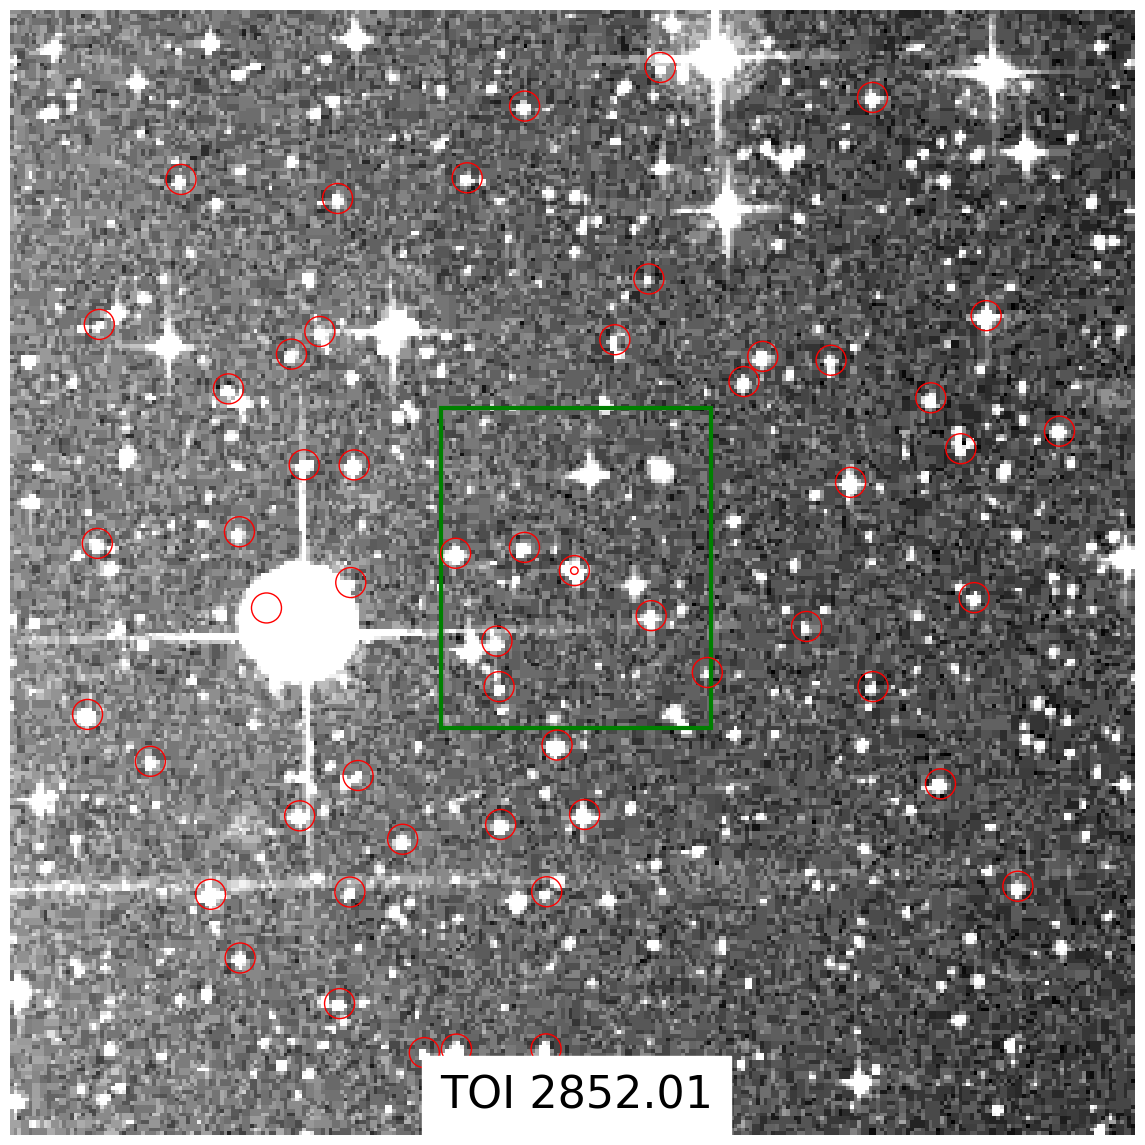

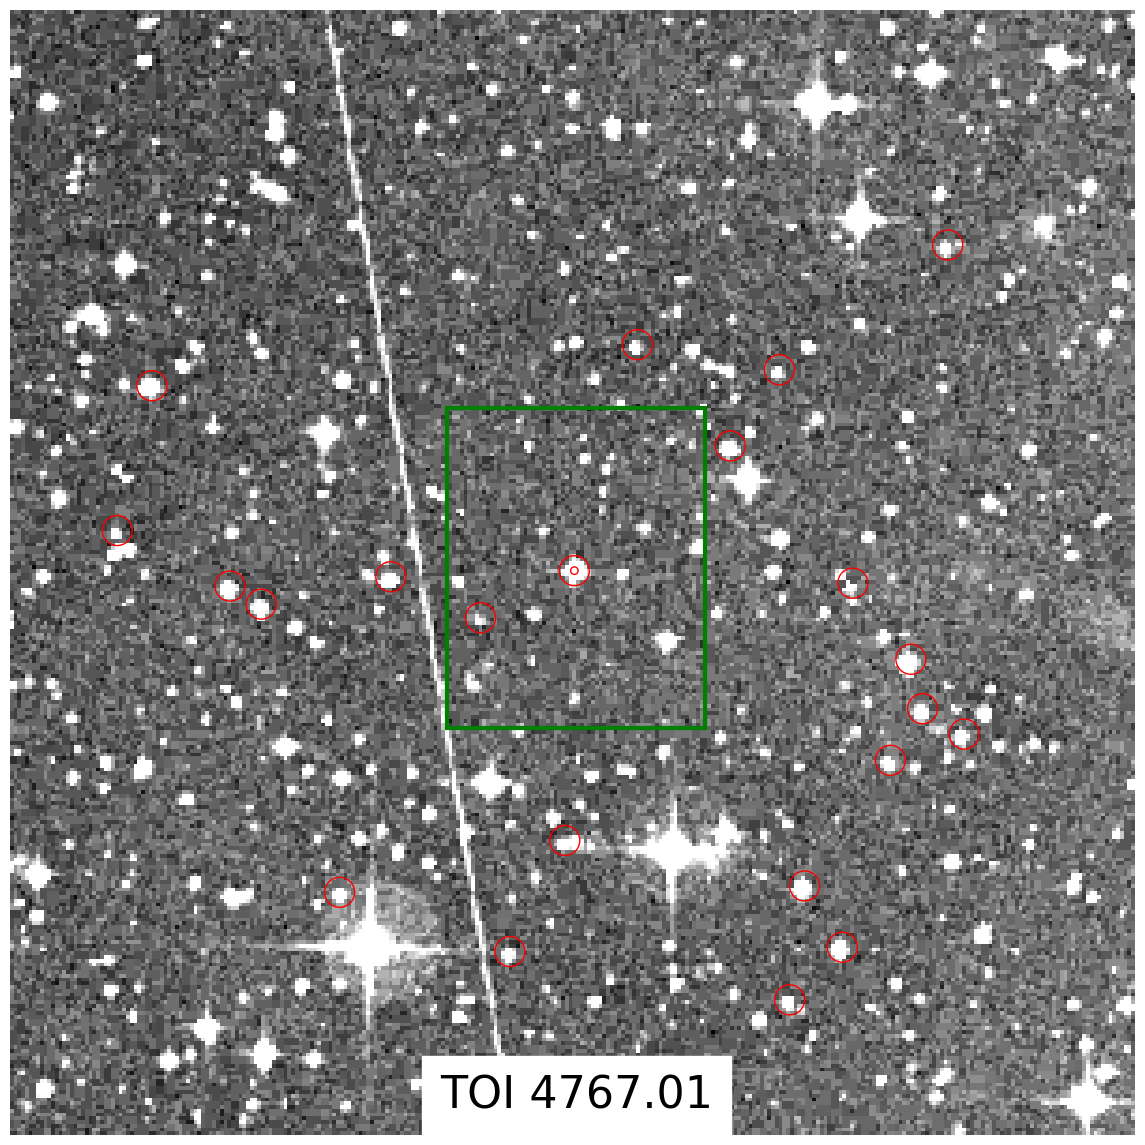

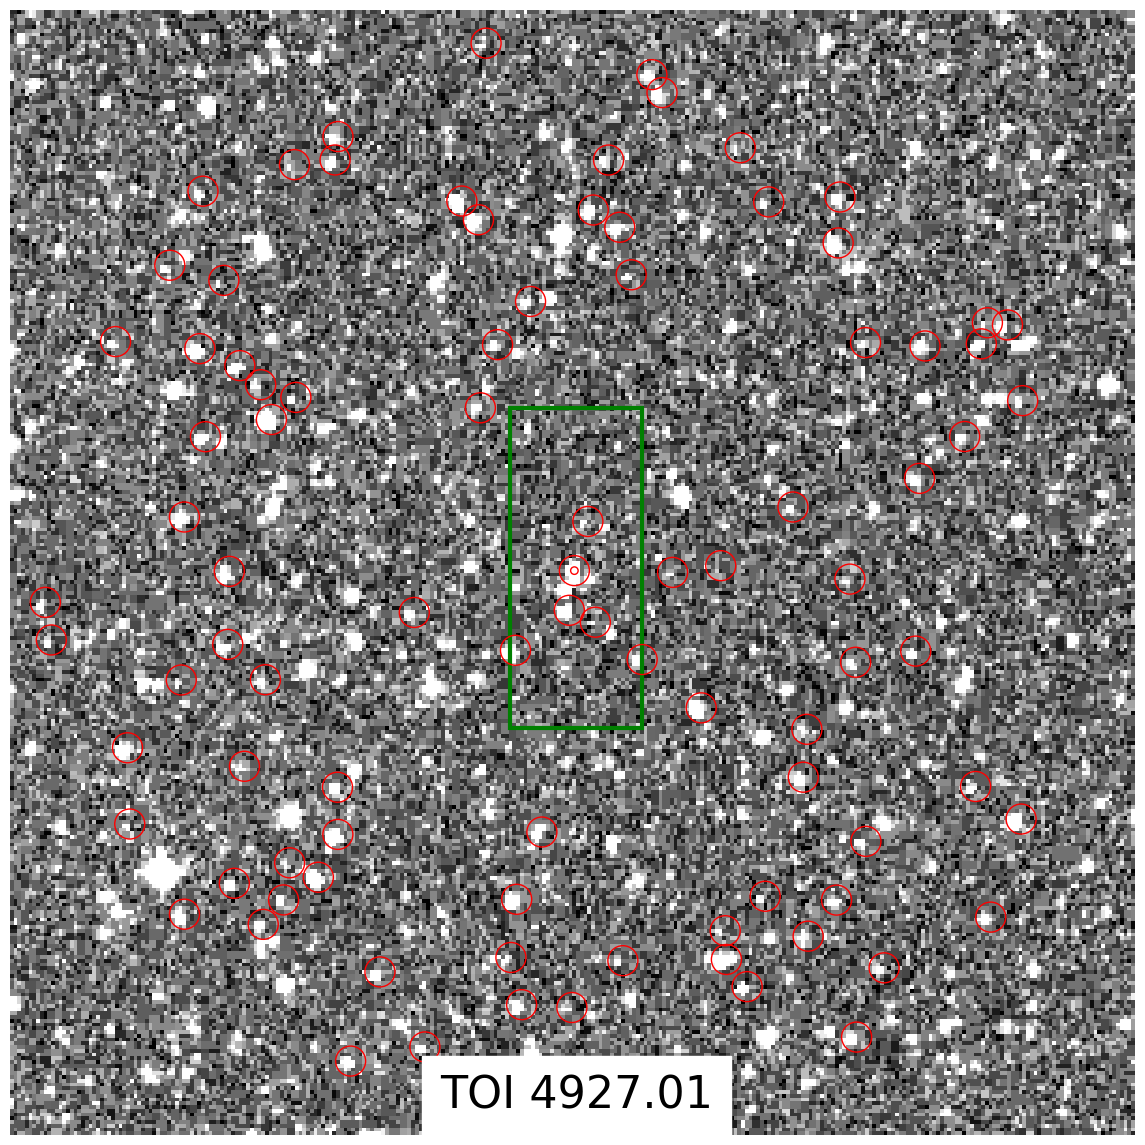

In [68]:
# getting the images for the final TOIs
for index, row in final_TOIs.iterrows():
    get_toi_image(str(row['RA (deg)']), str(row['Dec (deg)']), row['TOI'], row['TESS Mag'])